# Real World Classification

## Load data

Import the necessary libraries

In [1]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed=40
np.random.seed(seed)

load the data

In [2]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/NYCU_Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,7.0,NaN,4.700000,1.4,16.9,37.5,6.769877,6.755471,6.964281,...,0.466458,0.961982,-0.041964,-2.573335,-0.290155,1.346631,0.334072,0.303819,-1.318415,Iris-versicolor
1,2,6.4,3.2,4.500000,1.5,16.4,95.1,6.202714,6.129652,6.201464,...,-1.270085,1.283433,-1.155498,-0.295384,0.684086,-0.426519,0.113067,1.562539,0.095345,Iris-versicolor
2,3,6.9,NaN,4.900000,1.5,16.9,73.2,6.726317,6.762992,6.784647,...,0.562054,1.238704,0.345857,1.172525,0.320302,-0.563687,-1.514457,-0.179045,-0.577574,Iris-versicolor
3,4,5.5,2.3,5.085612,1.3,15.6,59.9,5.608292,5.529096,5.382254,...,-0.165898,0.914796,1.252364,-0.301381,-0.466333,-0.773040,-0.793858,0.483426,1.210299,Iris-versicolor
4,5,6.5,2.8,4.600000,1.5,16.4,15.6,6.300774,6.443553,6.274360,...,-0.602098,2.045948,-0.465691,0.862299,2.085633,2.047018,0.005283,0.506305,0.766709,Iris-versicolor


In [4]:
missing_cols = df.columns[df.isnull().any()].tolist()
df[missing_cols].describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength
count,472.000000,443.000000,350.000000,478.000000,476.000000
mean,6.320551,2.837472,5.085612,1.675732,16.302941
std,1.037115,0.389564,1.582807,0.706689,1.035228
min,3.000000,1.500000,0.500000,-1.000000,12.700000
25%,5.800000,2.600000,4.425000,1.300000,15.800000
50%,6.300000,2.900000,5.085612,1.600000,16.300000
75%,6.700000,3.100000,5.500000,2.000000,16.800000
max,9.600000,4.000000,9.200000,4.300000,19.700000


## Data Preprocessing

In [5]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # TODO: Replace the missing values using “Nearest Neighbors Imputation”
    # ---------- Start your code below ----------
    imputer = KNNImputer(n_neighbors=2, weights="uniform")
    df[feature_cols] = imputer.fit_transform(df[feature_cols])
    # ---------- --------------------- ----------
     
    return df, feature_cols

df, feature_cols = data_preprocessing(df)

In [7]:
df[missing_cols].describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,6.316700,2.842900,5.033324,1.685700,16.301200
std,1.011624,0.374386,1.615987,0.695383,1.013219
min,3.000000,1.500000,0.500000,-1.000000,12.700000
25%,5.800000,2.600000,4.400000,1.300000,15.800000
50%,6.300000,2.900000,5.085612,1.700000,16.300000
75%,6.700000,3.100000,5.400000,2.000000,16.700000
max,9.600000,4.000000,9.200000,4.300000,19.700000


In [6]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,250.500000,6.316700,2.842900,5.033324,1.685700,16.301200,46.745800,6.316422,6.323365,6.320980,...,0.068882,-0.029672,-0.015074,0.037059,0.082579,0.011686,0.077167,-0.034112,0.029674,0.5200
std,144.481833,1.011624,0.374386,1.615987,0.695383,1.013219,30.032428,1.009859,1.043500,1.024075,...,1.049557,1.046532,1.024190,0.995562,1.033822,1.011917,0.969005,0.949463,0.969047,0.5001
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,2.877573,2.944078,2.955459,...,-3.258345,-3.090824,-2.673773,-2.735569,-3.033392,-2.625754,-3.143116,-2.878216,-2.589544,0.0000
25%,125.750000,5.800000,2.600000,4.400000,1.300000,15.800000,18.500000,5.836615,5.801651,5.793089,...,-0.625022,-0.702388,-0.649046,-0.630572,-0.627218,-0.718793,-0.529432,-0.649448,-0.653394,0.0000
50%,250.500000,6.300000,2.900000,5.085612,1.700000,16.300000,44.000000,6.316422,6.310315,6.320980,...,0.076748,-0.047413,-0.044223,-0.022831,0.109614,-0.017135,0.112847,-0.019524,0.044542,1.0000
75%,375.250000,6.700000,3.100000,5.400000,2.000000,16.700000,73.200000,6.738205,6.797044,6.699885,...,0.806166,0.655584,0.641842,0.750853,0.816614,0.743847,0.751684,0.631034,0.674469,1.0000
max,500.000000,9.600000,4.000000,9.200000,4.300000,19.700000,98.700000,10.032204,10.146460,10.262641,...,3.333114,3.888629,3.174867,3.109433,3.507325,3.100138,2.626066,2.515151,3.254291,1.0000


## Data Exploration

In [8]:
from sklearn.feature_selection import r_regression

# TODO: Complete the 4. Data Exploration

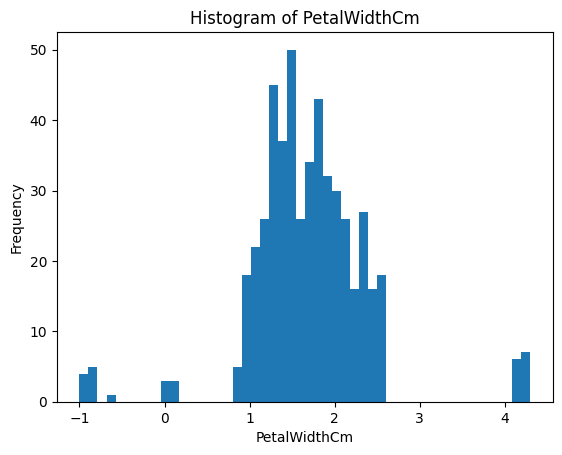

In [14]:
plt.hist(df['PetalWidthCm'], bins=50)
plt.title('Histogram of PetalWidthCm')
plt.xlabel('PetalWidthCm')
plt.ylabel('Frequency')
plt.show()

In [16]:
X = df.drop(columns=['PetalWidthCm', 'Species', 'Id'])
y = df['PetalWidthCm']
correlations = r_regression(X, y)
correlations

array([ 4.12911193e-02, -5.24843166e-02,  3.23861013e-01,  3.39282111e-02,
        9.37184168e-02,  3.68462640e-02,  3.36740427e-02,  2.71315922e-02,
        2.29616949e-02,  4.01807701e-02,  4.37018916e-02, -9.68308826e-02,
       -7.47935665e-02, -6.95857458e-02, -8.84720276e-02, -6.17570483e-02,
       -8.22649027e-02,  3.25707540e-01,  3.20568436e-01,  3.21245119e-01,
        3.23661077e-01,  3.24419343e-01,  3.25083306e-01,  9.90089236e-01,
        9.89948377e-01,  9.90498943e-01,  9.90617709e-01,  9.90043478e-01,
        9.90221298e-01, -2.28560298e-02, -6.45408607e-03, -1.50100494e-02,
       -9.46289163e-04,  2.68270988e-02,  4.46901296e-04, -4.15238982e-02,
       -7.45021007e-03, -1.29051228e-03,  2.28902474e-02,  5.30486203e-02,
        1.51086064e-02,  7.18003420e-03, -4.43890803e-02, -8.15020338e-03,
        6.71015931e-02, -4.12945069e-02, -9.19680313e-02, -5.25140383e-02,
        1.29488331e-01,  1.01553196e-02, -4.78667602e-02, -1.92643589e-03,
        1.02872688e-02,  

In [17]:
best_feature = X.columns[correlations.argmax()]
print("Highest positive correlation:", best_feature)

Highest positive correlation: PetalWidthCompactness


In [18]:
corr_df = pd.Series(correlations, index=X.columns)
top5_negative = corr_df.nsmallest(5)
print(top5_negative)

SepalWidthMajorAxis     -0.096831
SepalGlossIndex         -0.091968
SepalWidthCompactness   -0.088472
SepalWidthCurvature     -0.082265
SepalWidthMinorAxis     -0.074794
dtype: float64


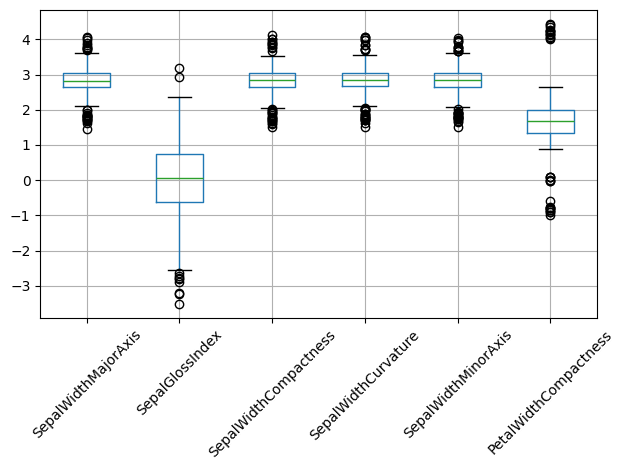

In [20]:
selected = list(top5_negative.index) + [best_feature]
df[selected].boxplot(rot=45)
plt.tight_layout()
plt.show()

## Model Training

### Prepare the data

In [21]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0
        
X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,0.606061,0.68,0.482759,0.452830,0.600000,0.376147,0.544026,0.529185,0.548614,...,0.565095,0.580677,0.449986,0.027756,0.419409,0.693758,0.602718,0.589990,0.217516,0
1,2,0.515152,0.68,0.459770,0.471698,0.528571,0.963303,0.464754,0.442295,0.444221,...,0.301642,0.626733,0.259595,0.417482,0.568359,0.384086,0.564410,0.823373,0.459439,0
2,3,0.590909,0.60,0.505747,0.471698,0.600000,0.740061,0.537937,0.530229,0.524031,...,0.579598,0.620325,0.516296,0.668622,0.512741,0.360130,0.282303,0.500461,0.344289,0
3,4,0.378788,0.32,0.527082,0.433962,0.414286,0.604485,0.381672,0.358911,0.332111,...,0.469160,0.573916,0.671291,0.416456,0.392474,0.323568,0.407208,0.623292,0.650231,0
4,5,0.530303,0.52,0.471264,0.471698,0.528571,0.152905,0.478459,0.485877,0.454197,...,0.402983,0.735985,0.377538,0.615546,0.782640,0.816078,0.545727,0.627534,0.574324,0


### Train the model!

50. Training loss: 0.6749532099816632, Val loss:0.6839860603316457
100. Training loss: 0.6746418455733307, Val loss:0.6838976589042444
150. Training loss: 0.6746359410363616, Val loss:0.6838968146130167
200. Training loss: 0.6746358256854245, Val loss:0.6838968162311606
250. Training loss: 0.6746358234297242, Val loss:0.6838968167165328
300. Training loss: 0.6746358233856385, Val loss:0.6838968167374014
350. Training loss: 0.6746358233847782, Val loss:0.683896816738094
400. Training loss: 0.6746358233847614, Val loss:0.6838968167381146
450. Training loss: 0.674635823384761, Val loss:0.6838968167381153
500. Training loss: 0.6746358233847611, Val loss:0.6838968167381153
550. Training loss: 0.674635823384761, Val loss:0.6838968167381153
600. Training loss: 0.674635823384761, Val loss:0.6838968167381153
650. Training loss: 0.674635823384761, Val loss:0.6838968167381153
700. Training loss: 0.674635823384761, Val loss:0.6838968167381153
750. Training loss: 0.674635823384761, Val loss:0.68389

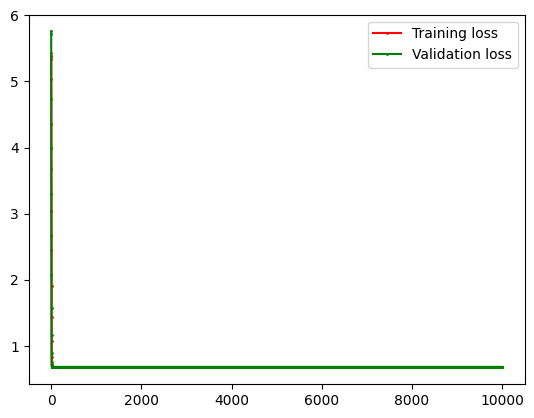

Model parameters (weights): [[-0.01260563]
 [ 0.02222563]
 [ 0.00897039]
 [ 0.02435244]
 [ 0.03665268]
 [ 0.01890893]
 [ 0.01763642]
 [ 0.01783048]
 [ 0.01917943]
 [ 0.02022247]
 [ 0.01908492]
 [ 0.02007628]
 [ 0.02089066]
 [ 0.00450834]
 [ 0.0030419 ]
 [ 0.0059773 ]
 [ 0.00697674]
 [ 0.00735267]
 [ 0.00619665]
 [ 0.02317734]
 [ 0.02375388]
 [ 0.02555181]
 [ 0.02380917]
 [ 0.02509971]
 [ 0.02365109]
 [ 0.03456469]
 [ 0.03516373]
 [ 0.03656312]
 [ 0.0364329 ]
 [ 0.03665013]
 [ 0.03664495]
 [-0.0131044 ]
 [ 0.00450027]
 [-0.00650988]
 [-0.00244244]
 [-0.00525517]
 [-0.00341934]
 [-0.01249291]
 [-0.02760227]
 [-0.00528961]
 [-0.00989597]
 [-0.00416301]
 [-0.01544237]
 [-0.00706338]
 [-0.00182434]
 [-0.00558007]
 [-0.00869161]
 [-0.00530124]
 [-0.01150991]
 [-0.00887166]
 [-0.00140348]
 [-0.00762498]
 [-0.00638499]
 [-0.00805243]
 [-0.00215524]
 [-0.00164309]
 [-0.00845257]
 [-0.01323779]
 [-0.00868654]
 [-0.01066375]
 [-0.01531098]
 [-0.00048582]
 [ 0.00436711]
 [-0.01260446]
 [-0.0094921

In [28]:
# Use the LinearModel to fit the data

from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

np.random.seed(seed)
model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
model.fit(X_train, y_train, lr=0.1, n_iteration=10000, val_ratio=0.2, reg_type='l2', reg_lambda=100)

# print model parameters
print("Model parameters (weights):", model.W)
# sum of absolute values of weights
print("Sum of absolute values of weights:", np.sum(np.abs(model.W)))

## Metrics

Model Evaluation
Accuracy  : 0.5067
Precision : 0.5067
Recall    : 1.0000
F1-score  : 0.6726


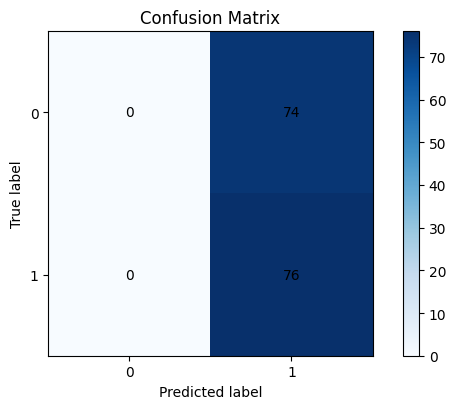

{'Accuracy': 0.5066666666666667,
 'Precision': 0.5066666666666667,
 'Recall': 1.0,
 'F1-score': 0.672566371681416}

In [29]:
# use evaluate_binary_classifier to evaluate the model on the test set
from model.metrics import evaluate_binary_classifier

y_pred = model.predict(X_test)
evaluate_binary_classifier(y_test, y_pred)